In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from sklearn import metrics
import sklearn
import matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


folder_path = "/content/drive/MyDrive/Colab Notebooks/"

Mounted at /content/drive


In [ ]:
Cc = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Adra1a eLacco fiberphoto.xlsx", sheet_name='Cont_CNO')

In [ ]:
eC = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Lactate fiberphoto.xlsx", sheet_name='e-airpuff-CNO')
eS = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Lactate fiberphoto.xlsx", sheet_name='e-airpuff-saline')

In [ ]:
e01C = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Lactate fiberphoto.xlsx", sheet_name='e-airpuff-01CNO')

In [ ]:
def idx_of_the_nearest(data, value):
  '''
  一番近いインデックスを取得
  '''
  idx = np.argmin(np.abs(np.array(data) - value))

  return idx

In [ ]:
def dFF_func(time, iso, green, BC_start_sec, BC_end_sec, BL_start_sec, BL_end_sec, fitting, mouse):
    '''
    dF/Fを算出する関数
    fitting: 1だったら470でfitting, 0だったら405でfitting
    '''
    BC_start = idx_of_the_nearest(time, BC_start_sec)
    BC_end = idx_of_the_nearest(time, BC_end_sec)

    BL_start = idx_of_the_nearest(time, BL_start_sec)
    BL_end = idx_of_the_nearest(time, BL_end_sec)


    add1 = [1 for i in range(len(green))]

    fit = np.polyfit(time, iso, 1)
    fittedIso = fit[0] * np.array(time) + fit[1]
    isoBC = iso - fittedIso
    isoBCN = isoBC + add1

    fit = np.polyfit(time[BC_start:BC_end], green[BC_start:BC_end], 1)
    fittedGreen = fit[0] * np.array(time) + fit[1]

    if fitting == 1:
        greenBC = green - fittedGreen
        greenBCN = greenBC + add1

    else:
        greenBC = green - fittedIso
        greenBCN = greenBC + add1

    BL_mean = np.mean(greenBCN[BL_start:BL_end] / isoBCN[BL_start:BL_end])
    dFF = greenBCN / isoBCN - BL_mean

    fig_func(time, iso, green, fittedIso, fittedGreen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse)

    return dFF

In [ ]:
def fig_func(time, iso, green, fittedIso, fittedGeen, isoBCN, greenBCN, dFF, BC_start, BC_end, BL_start, BL_end, fitting, mouse):

    plt.figure(figsize=(50, 2))
    plt.subplots_adjust(wspace=0.1, hspace=0.1)

    #plt.subplot(1, 3, 1)
    #plt.plot(time, iso, color="gray")
    #plt.plot(time, green, color="black")

    if fitting == 1:
        plt.plot(time[BC_start:BC_end], green[BC_start:BC_end], color="red")
        plt.plot(time, fittedIso, color="blue")

    if fitting == 1:
        plt.plot(time, fittedGeen, color="blue")
    else:
        plt.plot(time, fittedIso, color="blue")


    #plt.subplot(1, 3, 2)
    #plt.plot(time, isoBCN, color="gray")
    #plt.plot(time, greenBCN, color="black")

    plt.subplot(1, 3, 3)
    plt.plot(time, dFF, color="green")
    plt.plot(time[BL_start:BL_end], dFF[BL_start:BL_end], color='red')

    plt.title('{}'.format(mouse))

In [ ]:
time_ = [float(_) for _ in np.array(Cc.filter(like=('Time'), axis=1))][10:-9]

/tmp/ipykernel_3277/488121925.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time_ = [float(_) for _ in np.array(Cc.filter(like=('Time'), axis=1))][10:-9]


In [ ]:
Cont1_CNO = np.array(Cc.filter(['Cont1_iso', 'Cont1_green']))[10:-9]
Cont2_CNO = np.array(Cc.filter(['Cont2_iso', 'Cont2_green']))[10:-9]
Cont3_CNO = np.array(Cc.filter(['Cont3_iso', 'Cont3_green']))[10:-9]
Cont4_CNO = np.array(Cc.filter(['Cont4_iso', 'Cont4_green']))[10:-9]
Cont5_CNO = np.array(Cc.filter(['Cont5_iso', 'Cont5_green']))[10:-9]
Cont6_CNO = np.array(Cc.filter(['Cont6_iso', 'Cont6_green']))[10:-9]
Cont7_CNO = np.array(Cc.filter(['Cont7_iso', 'Cont7_green']))[10:-9]
Cont8_CNO = np.array(Cc.filter(['Cont8_iso', 'Cont8_green']))[10:-9]

In [ ]:
hM3Dq1_CNO = np.array(eC.filter(['e-lacco1_CNO_iso', 'e-lacco1_CNO_green']))[10:-9]
hM3Dq2_CNO = np.array(eC.filter(['e-lacco2_CNO_iso', 'e-lacco2_CNO_green']))[10:-9]
hM3Dq3_CNO = np.array(eC.filter(['e-lacco3_CNO_iso', 'e-lacco3_CNO_green']))[10:-9]
hM3Dq4_CNO = np.array(eC.filter(['e-lacco4_CNO_iso', 'e-lacco4_CNO_green']))[10:-9]
hM3Dq5_CNO = np.array(eC.filter(['e-lacco5_CNO_iso', 'e-lacco5_CNO_green']))[10:-9]
hM3Dq6_CNO = np.array(eC.filter(['e-lacco6_CNO_iso', 'e-lacco6_CNO_green']))[10:-9]
hM3Dq7_CNO = np.array(eC.filter(['e-lacco7_CNO_iso', 'e-lacco7_CNO_green']))[10:-9]

In [ ]:
hM3Dq1_saline = np.array(eS.filter(['e-lacco1_saline_iso', 'e-lacco1_saline_green']))[10:-9]
hM3Dq2_saline = np.array(eS.filter(['e-lacco2_saline_iso', 'e-lacco2_saline_green']))[10:-9]
hM3Dq3_saline = np.array(eS.filter(['e-lacco3_saline_iso', 'e-lacco3_saline_green']))[10:-9]
hM3Dq4_saline = np.array(eS.filter(['e-lacco4_saline_iso', 'e-lacco4_saline_green']))[10:-9]
hM3Dq5_saline = np.array(eS.filter(['e-lacco5_saline_iso', 'e-lacco5_saline_green']))[10:-9]
hM3Dq6_saline = np.array(eS.filter(['e-lacco6_saline_iso', 'e-lacco6_saline_green']))[10:-9]
hM3Dq7_saline = np.array(eS.filter(['e-lacco7_saline_iso', 'e-lacco7_saline_green']))[10:-9]

In [ ]:
hM3Dq1_01CNO = np.array(e01C.filter(['e-lacco1_01CNO_iso', 'e-lacco1_01CNO_green']))[10:-9]
hM3Dq2_01CNO = np.array(e01C.filter(['e-lacco2_01CNO_iso', 'e-lacco2_01CNO_green']))[10:-9]
hM3Dq3_01CNO = np.array(e01C.filter(['e-lacco3_01CNO_iso', 'e-lacco3_01CNO_green']))[10:-9]
hM3Dq4_01CNO = np.array(e01C.filter(['e-lacco4_01CNO_iso', 'e-lacco4_01CNO_green']))[10:-9]
hM3Dq5_01CNO = np.array(e01C.filter(['e-lacco5_01CNO_iso', 'e-lacco5_01CNO_green']))[10:-9]
hM3Dq6_01CNO = np.array(e01C.filter(['e-lacco6_01CNO_iso', 'e-lacco6_01CNO_green']))[10:-9]
hM3Dq7_01CNO = np.array(e01C.filter(['e-lacco7_01CNO_iso', 'e-lacco7_01CNO_green']))[10:-9]

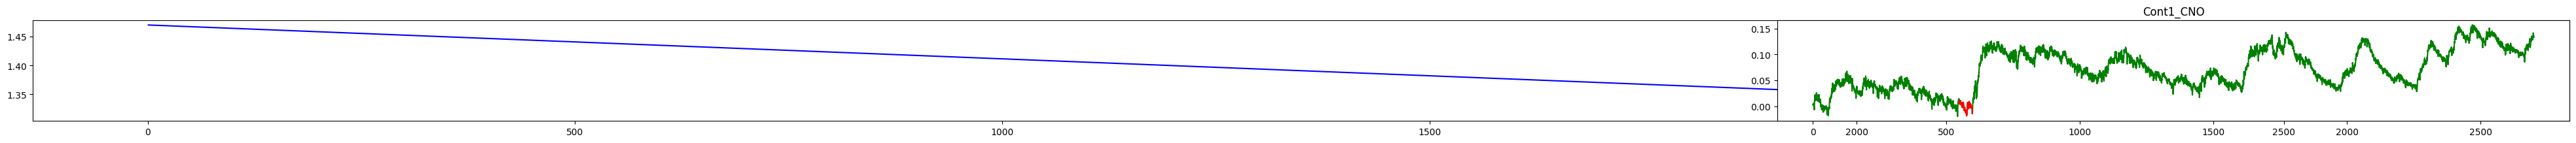

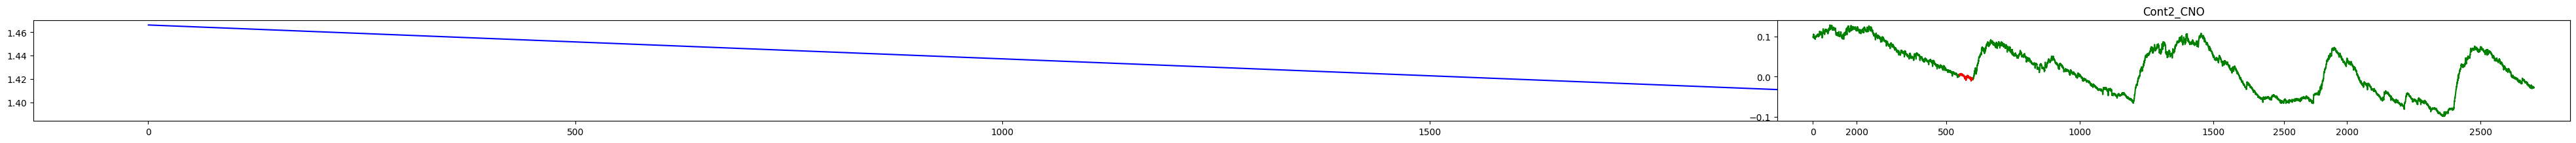

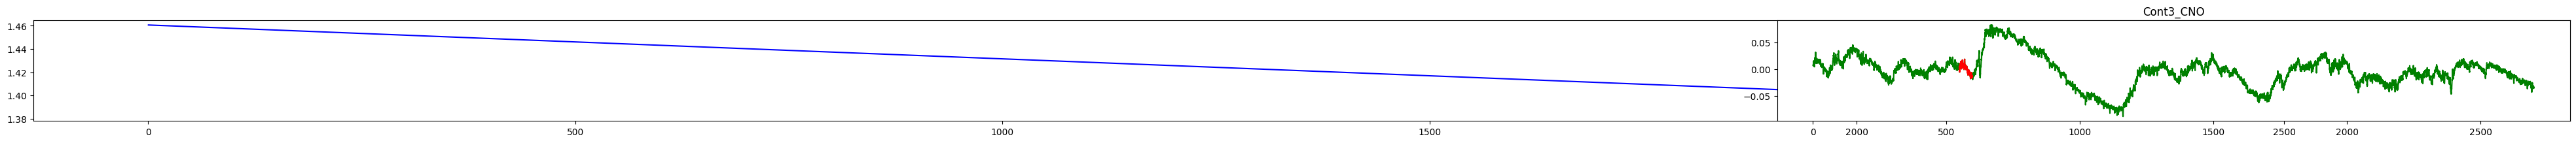

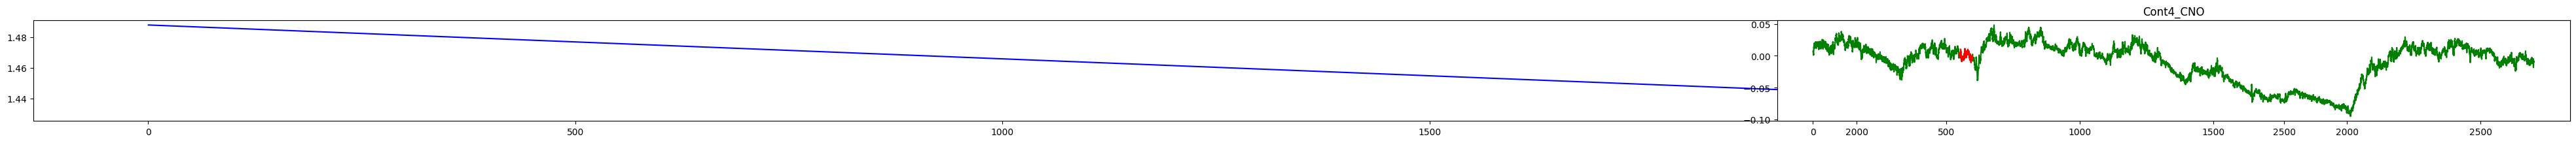

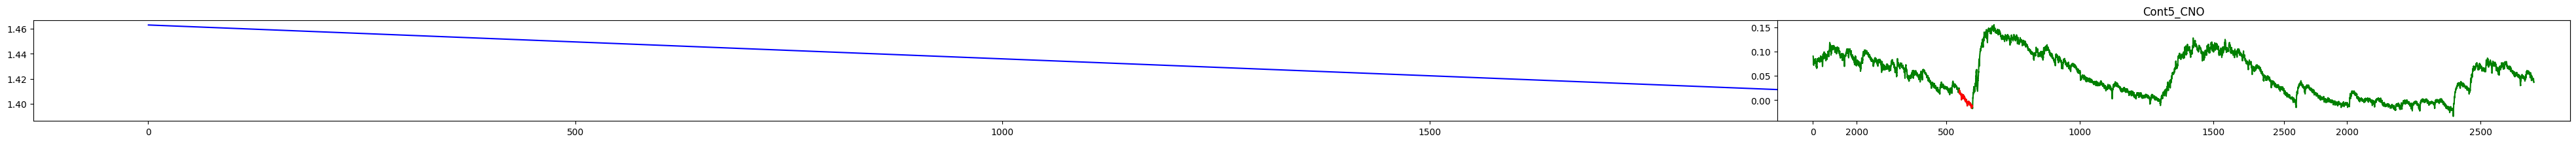

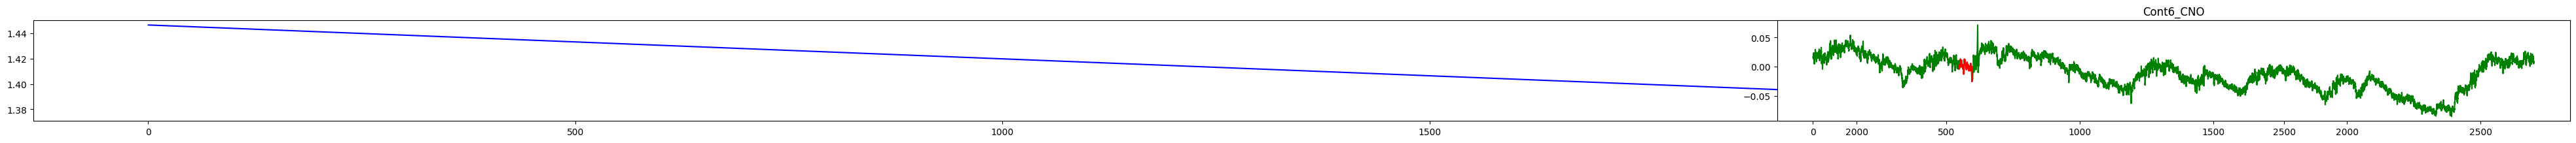

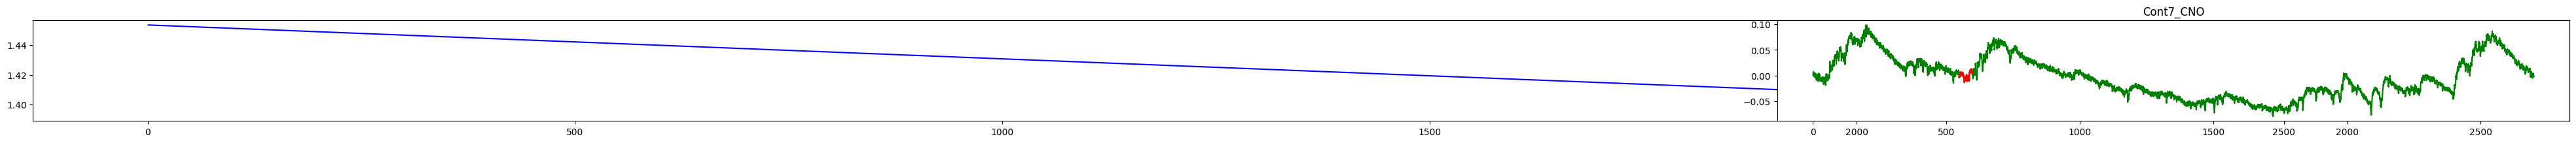

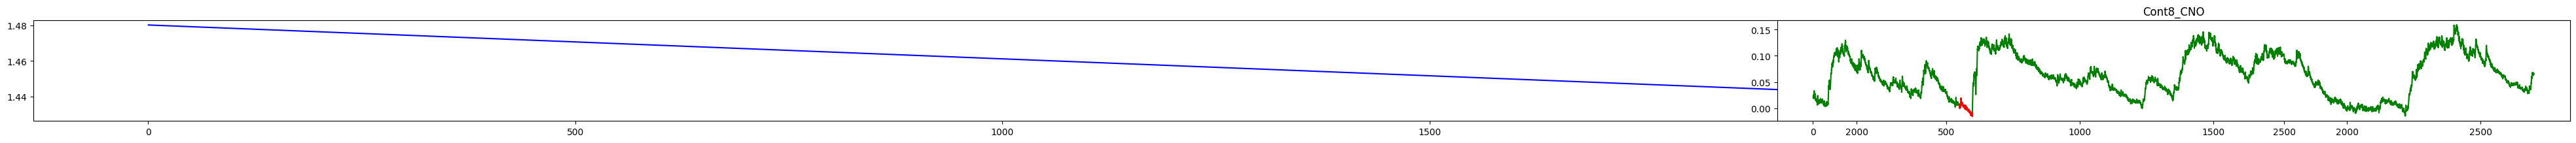

In [ ]:
Cont1_CNO_dFF = dFF_func(time_, Cont1_CNO[:,0], Cont1_CNO[:,1], 0, 2700, 548, 597, 0, "Cont1_CNO")
Cont2_CNO_dFF = dFF_func(time_, Cont2_CNO[:,0], Cont2_CNO[:,1], 0, 2700, 548, 597, 0, "Cont2_CNO")
Cont3_CNO_dFF = dFF_func(time_, Cont3_CNO[:,0], Cont3_CNO[:,1], 0, 2700, 548, 597, 0, "Cont3_CNO")
Cont4_CNO_dFF = dFF_func(time_, Cont4_CNO[:,0], Cont4_CNO[:,1], 0, 2700, 548, 597, 0, "Cont4_CNO")
Cont5_CNO_dFF = dFF_func(time_, Cont5_CNO[:,0], Cont5_CNO[:,1], 0, 2700, 548, 597, 0, "Cont5_CNO")
Cont6_CNO_dFF = dFF_func(time_, Cont6_CNO[:,0], Cont6_CNO[:,1], 0, 2700, 548, 597, 0, "Cont6_CNO")
Cont7_CNO_dFF = dFF_func(time_, Cont7_CNO[:,0], Cont7_CNO[:,1], 0, 2700, 548, 597, 0, "Cont7_CNO")
Cont8_CNO_dFF = dFF_func(time_, Cont8_CNO[:,0], Cont8_CNO[:,1], 0, 2700, 548, 597, 0, "Cont8_CNO")

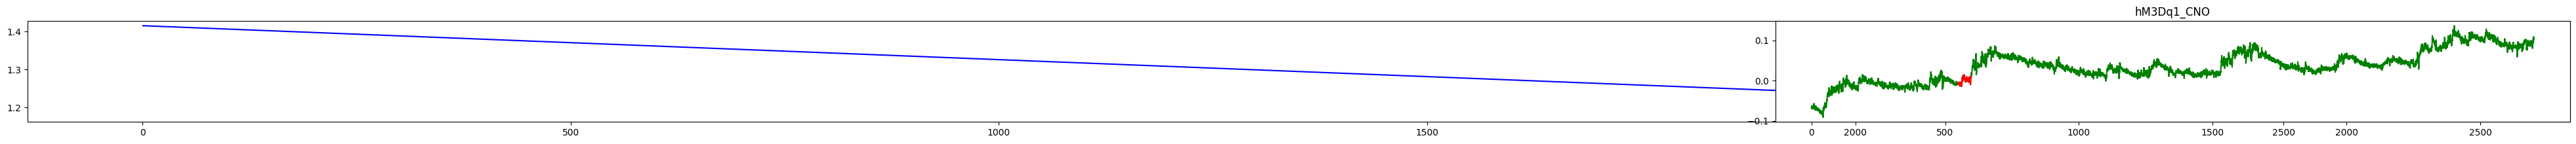

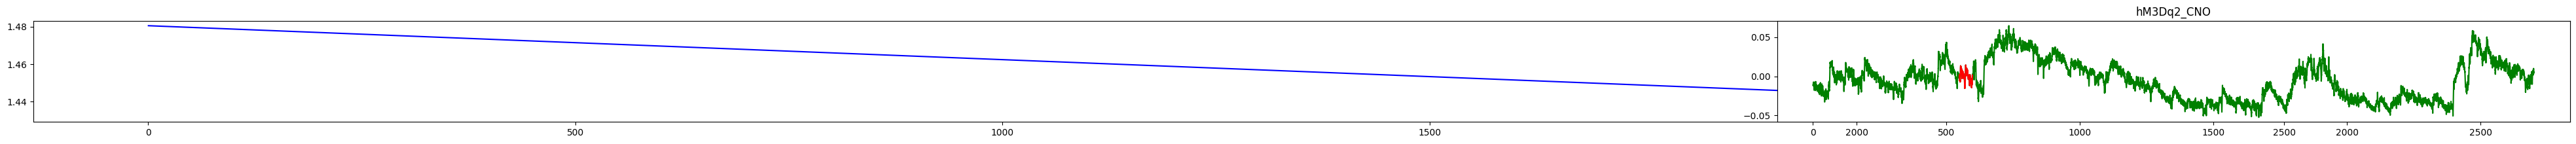

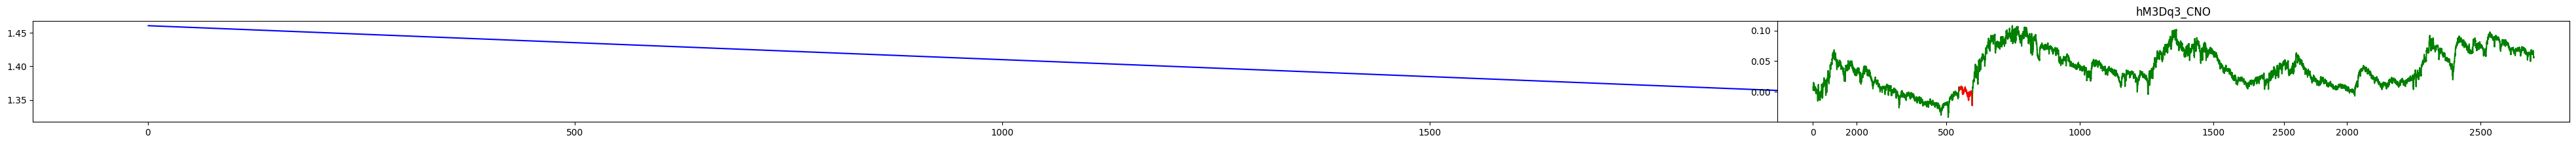

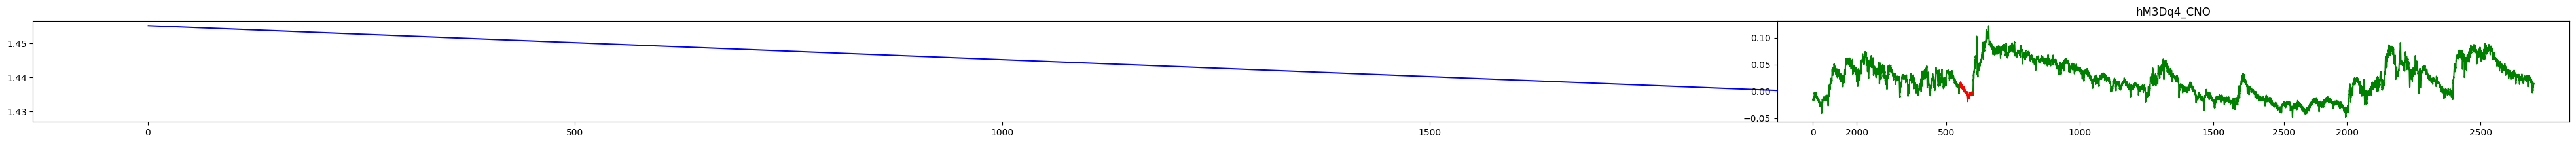

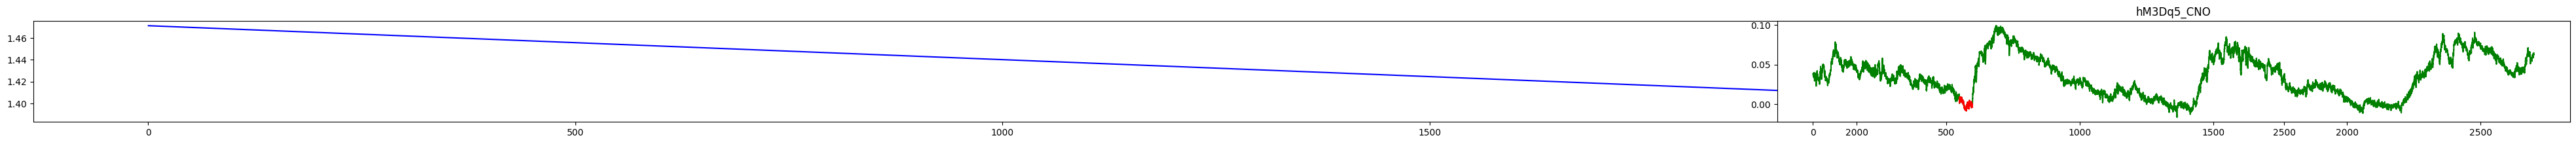

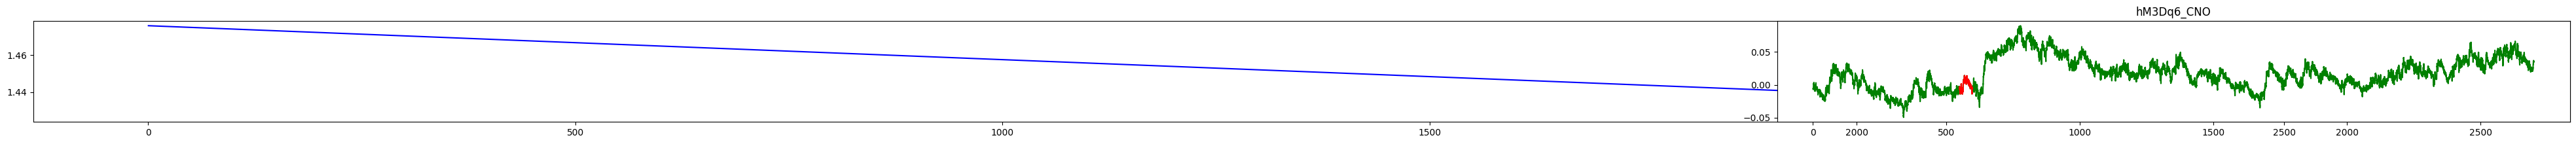

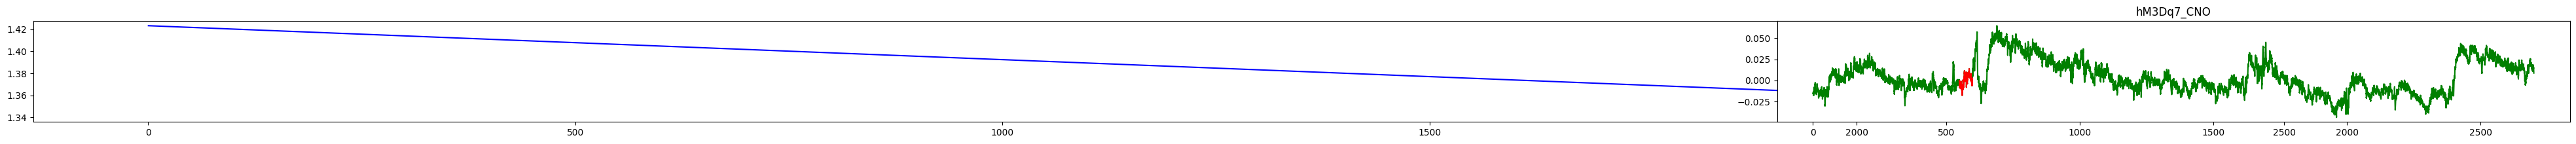

In [ ]:
hM3Dq1_CNO_dFF = dFF_func(time_, hM3Dq1_CNO[:,0], hM3Dq1_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq1_CNO")
hM3Dq2_CNO_dFF = dFF_func(time_, hM3Dq2_CNO[:,0], hM3Dq2_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq2_CNO")
hM3Dq3_CNO_dFF = dFF_func(time_, hM3Dq3_CNO[:,0], hM3Dq3_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq3_CNO")
hM3Dq4_CNO_dFF = dFF_func(time_, hM3Dq4_CNO[:,0], hM3Dq4_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq4_CNO")
hM3Dq5_CNO_dFF = dFF_func(time_, hM3Dq5_CNO[:,0], hM3Dq5_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq5_CNO")
hM3Dq6_CNO_dFF = dFF_func(time_, hM3Dq6_CNO[:,0], hM3Dq6_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq6_CNO")
hM3Dq7_CNO_dFF = dFF_func(time_, hM3Dq7_CNO[:,0], hM3Dq7_CNO[:,1], 0, 2700, 548, 597, 0, "hM3Dq7_CNO")

In [ ]:
print(hM3Dq2_saline)

[[1.4572454  1.46268782]
 [1.457458   1.46232424]
 [1.45755043 1.4620192 ]
 ...
 [       nan        nan]
 [       nan        nan]
 [       nan        nan]]


In [ ]:
hM3Dq1_saline_dFF = dFF_func(time_, hM3Dq1_saline[:,0], hM3Dq1_saline[:,1], 0, 2700, 548, 597, 0, "hM3Dq1_saline")
hM3Dq2_saline_dFF = dFF_func(time_, hM3Dq2_saline[:,0], hM3Dq2_saline[:,1], 0, 2600, 548, 597, 0, "hM3Dq2_saline")
hM3Dq3_saline_dFF = dFF_func(time_, hM3Dq3_saline[:,0], hM3Dq3_saline[:,1], 0, 2700, 548, 597, 0, "hM3Dq3_saline")
hM3Dq4_saline_dFF = dFF_func(time_, hM3Dq4_saline[:,0], hM3Dq4_saline[:,1], 0, 2700, 548, 597, 0, "hM3Dq4_saline")
hM3Dq5_saline_dFF = dFF_func(time_, hM3Dq5_saline[:,0], hM3Dq5_saline[:,1], 0, 2700, 548, 597, 0, "hM3Dq5_saline")
hM3Dq6_saline_dFF = dFF_func(time_, hM3Dq6_saline[:,0], hM3Dq6_saline[:,1], 0, 2700, 548, 597, 0, "hM3Dq6_saline")
hM3Dq7_saline_dFF = dFF_func(time_, hM3Dq7_saline[:,0], hM3Dq7_saline[:,1], 0, 2700, 548, 597, 0, "hM3Dq7_saline")


NameError: name 'hM3Dq1_saline' is not defined

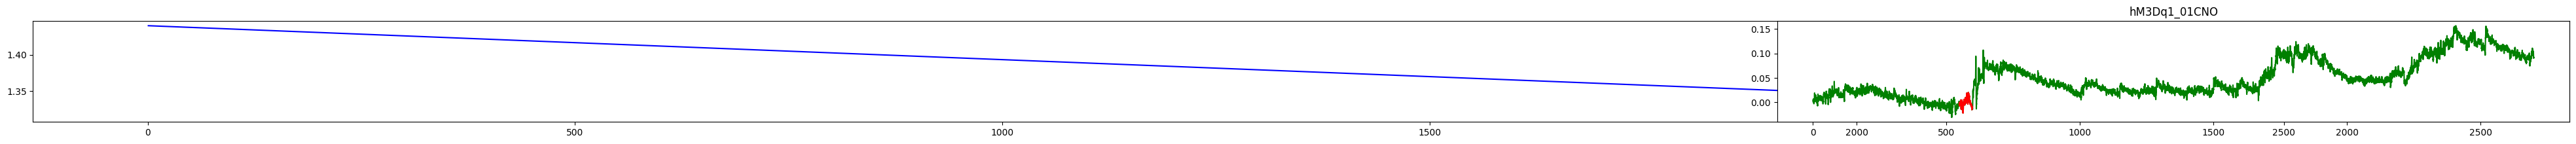

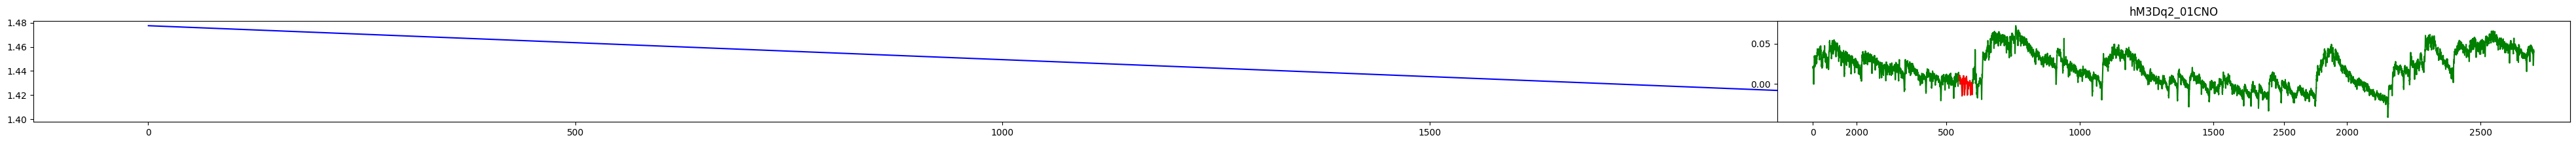

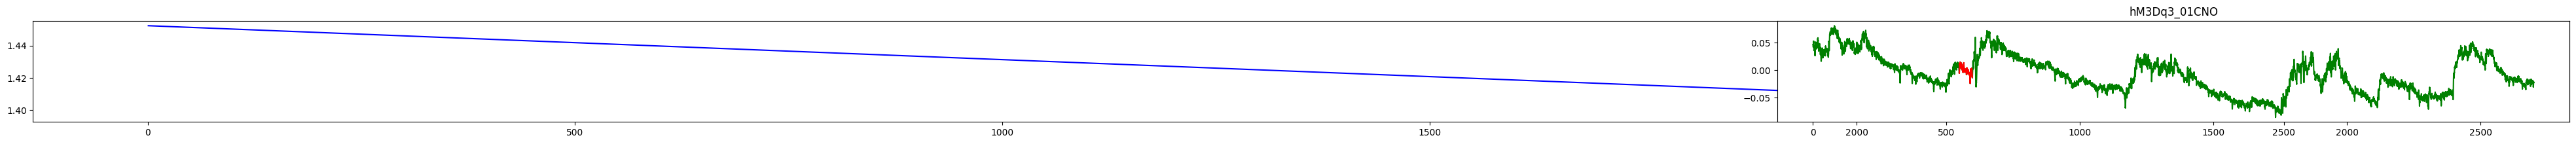

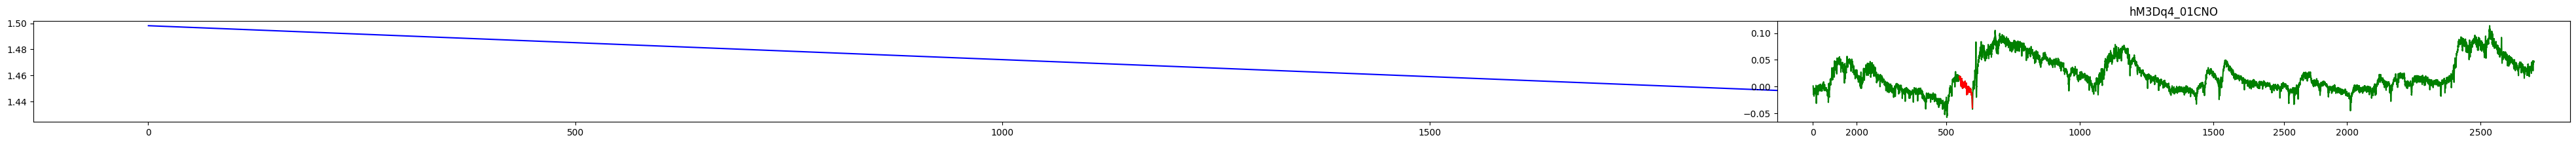

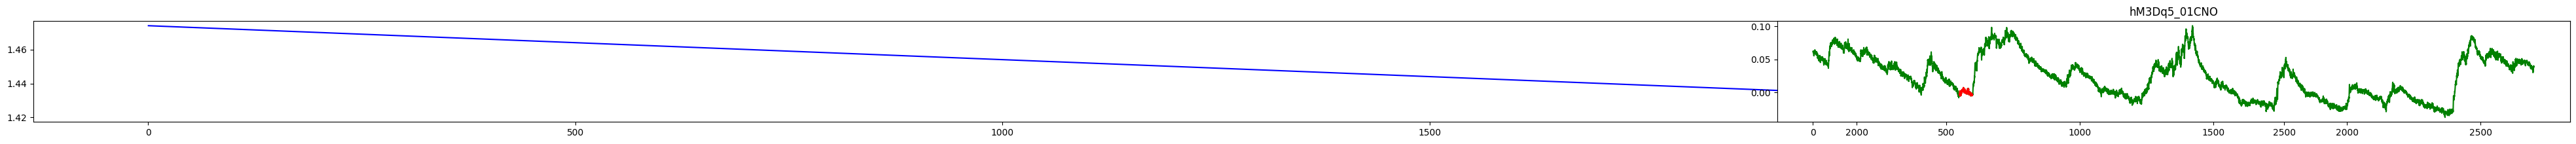

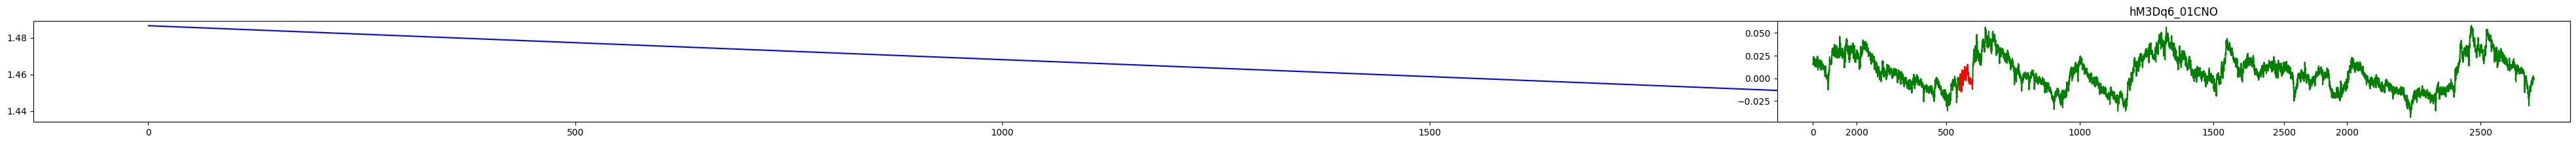

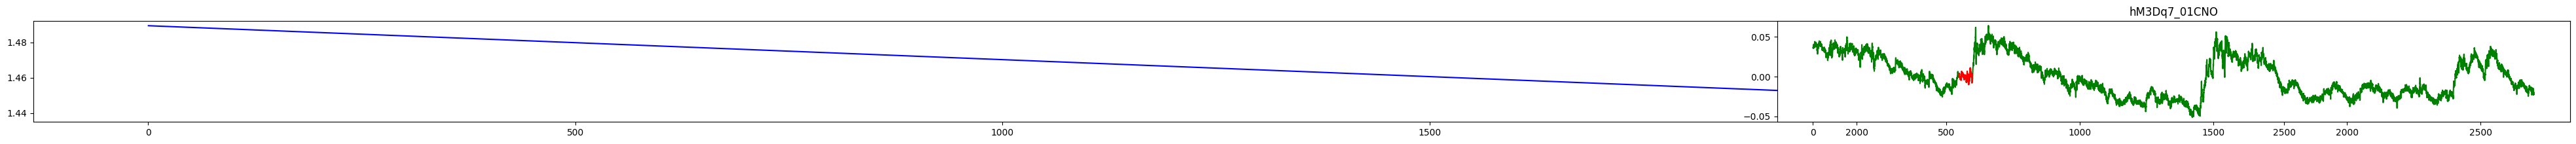

In [ ]:
hM3Dq1_01CNO_dFF = dFF_func(time_, hM3Dq1_01CNO[:,0], hM3Dq1_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq1_01CNO")
hM3Dq2_01CNO_dFF = dFF_func(time_, hM3Dq2_01CNO[:,0], hM3Dq2_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq2_01CNO")
hM3Dq3_01CNO_dFF = dFF_func(time_, hM3Dq3_01CNO[:,0], hM3Dq3_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq3_01CNO")
hM3Dq4_01CNO_dFF = dFF_func(time_, hM3Dq4_01CNO[:,0], hM3Dq4_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq4_01CNO")
hM3Dq5_01CNO_dFF = dFF_func(time_, hM3Dq5_01CNO[:,0], hM3Dq5_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq5_01CNO")
hM3Dq6_01CNO_dFF = dFF_func(time_, hM3Dq6_01CNO[:,0], hM3Dq6_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq6_01CNO")
hM3Dq7_01CNO_dFF = dFF_func(time_, hM3Dq7_01CNO[:,0], hM3Dq7_01CNO[:,1], 0, 2700, 2348, 2397, 0, "hM3Dq7_01CNO")

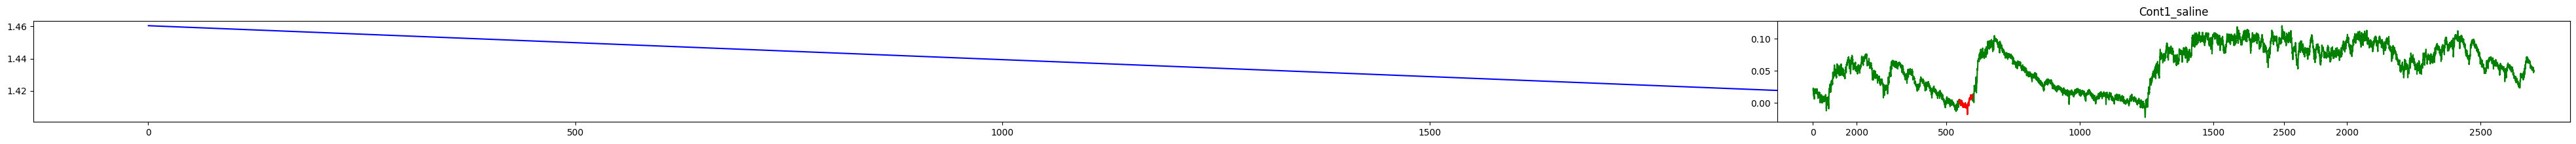

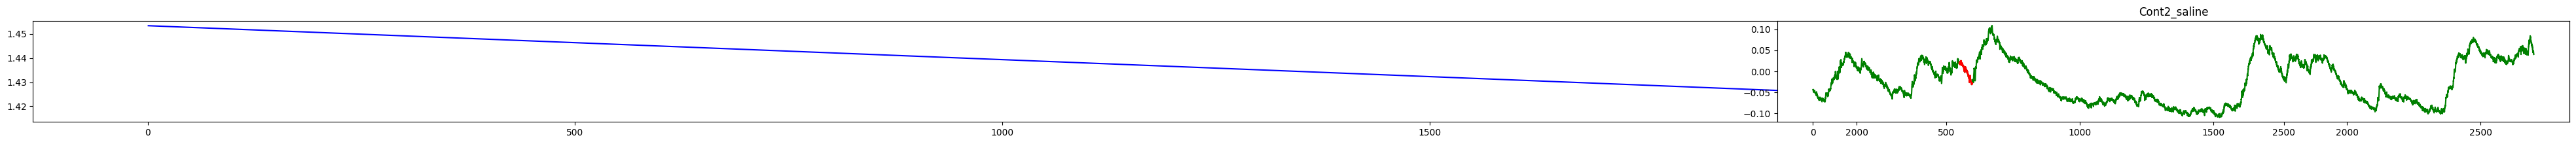

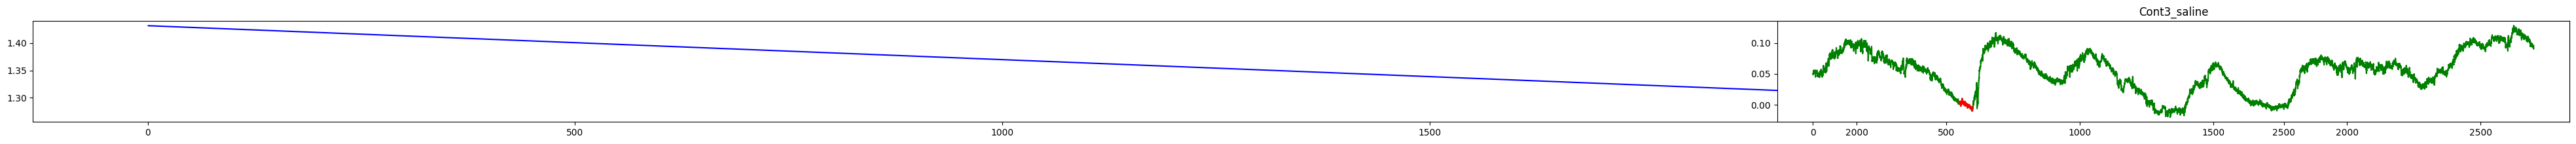

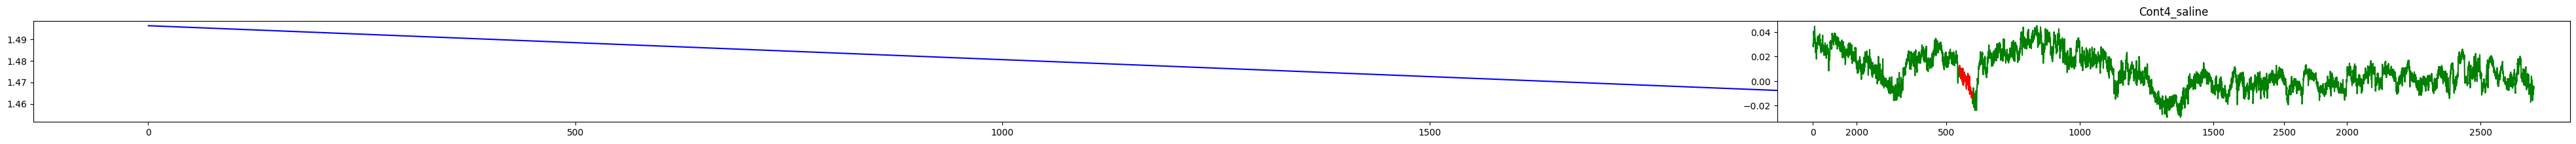

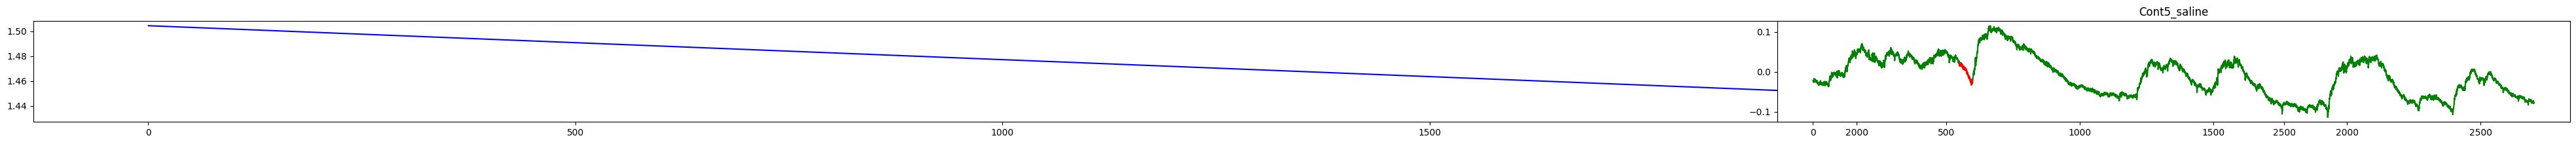

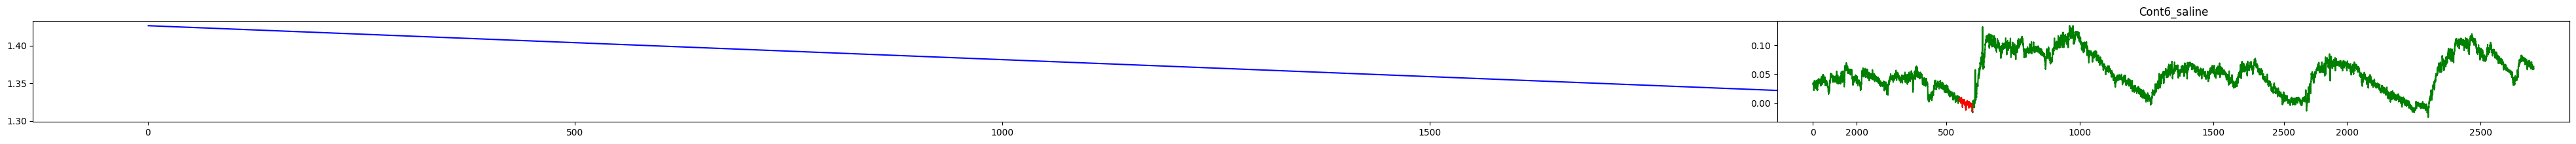

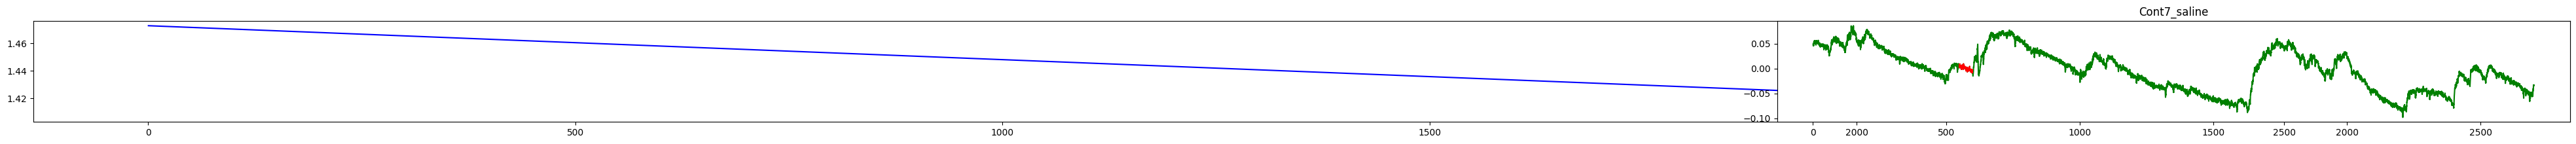

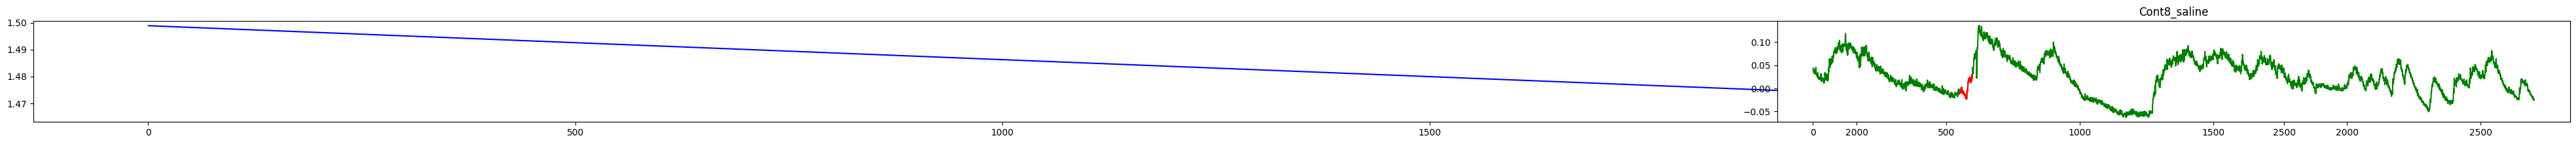

In [ ]:
Cont1_saline_dFF = dFF_func(time_, Cont1_saline[:,0], Cont1_saline[:,1], 0, 2700, 548, 597, 0, "Cont1_saline")
Cont2_saline_dFF = dFF_func(time_, Cont2_saline[:,0], Cont2_saline[:,1], 0, 2700, 548, 597, 0, "Cont2_saline")
Cont3_saline_dFF = dFF_func(time_, Cont3_saline[:,0], Cont3_saline[:,1], 0, 2700, 548, 597, 0, "Cont3_saline")
Cont4_saline_dFF = dFF_func(time_, Cont4_saline[:,0], Cont4_saline[:,1], 0, 2700, 548, 597, 0, "Cont4_saline")
Cont5_saline_dFF = dFF_func(time_, Cont5_saline[:,0], Cont5_saline[:,1], 0, 2700, 548, 597, 0, "Cont5_saline")
Cont6_saline_dFF = dFF_func(time_, Cont6_saline[:,0], Cont6_saline[:,1], 0, 2700, 548, 597, 0, "Cont6_saline")
Cont7_saline_dFF = dFF_func(time_, Cont7_saline[:,0], Cont7_saline[:,1], 0, 2700, 548, 597, 0, "Cont7_saline")
Cont8_saline_dFF = dFF_func(time_, Cont8_saline[:,0], Cont8_saline[:,1], 0, 2700, 548, 597, 0, "Cont8_saline")

In [ ]:
Cont_CNO_dFF = pd.DataFrame([Cont1_CNO_dFF, Cont2_CNO_dFF, Cont3_CNO_dFF, Cont5_CNO_dFF, Cont6_CNO_dFF, Cont7_CNO_dFF]).T

Cont_CNO_dFF.columns = ["Cont1_CNO", "Cont2_CNO", "Cont3_CNO", "Cont5_CNO", "Cont6_CNO", "Cont7_CNO"]
Cont_CNO_dFF.index = time_

In [ ]:
hM3Dq_CNO_dFF = pd.DataFrame([hM3Dq1_CNO_dFF, hM3Dq2_CNO_dFF, hM3Dq3_CNO_dFF, hM3Dq5_CNO_dFF, hM3Dq6_CNO_dFF, hM3Dq7_CNO_dFF]).T

hM3Dq_CNO_dFF.columns = ["hM3Dq1_CNO", "hM3Dq2_CNO", "hM3Dq3_CNO", "hM3Dq5_CNO", "hM3Dq6_CNO", "hM3Dq7_CNO"]
hM3Dq_CNO_dFF.index = time_

In [ ]:
hM3Dq_saline_dFF = pd.DataFrame([hM3Dq1_saline_dFF, hM3Dq3_saline_dFF, hM3Dq4_saline_dFF, hM3Dq5_saline_dFF, hM3Dq6_saline_dFF, hM3Dq7_saline_dFF]).T

hM3Dq_saline_dFF.columns = ["hM3Dq1_saline", "hM3Dq3_saline", "hM3Dq4_saline", "hM3Dq5_saline", "hM3Dq6_saline", "hM3Dq7_saline"]
hM3Dq_saline_dFF.index = time_

In [ ]:
hM3Dq_01CNO_dFF = pd.DataFrame([hM3Dq1_01CNO_dFF, hM3Dq2_01CNO_dFF, hM3Dq3_01CNO_dFF, hM3Dq4_01CNO_dFF, hM3Dq5_01CNO_dFF, hM3Dq6_01CNO_dFF, hM3Dq7_01CNO_dFF]).T

hM3Dq_01CNO_dFF.columns = ["hM3Dq1_01CNO", "hM3Dq2_01CNO", "hM3Dq3_01CNO", "hM3Dq4_01CNO", "hM3Dq5_01CNO", "hM3Dq6_01CNO", "hM3Dq7_01CNO"]
hM3Dq_01CNO_dFF.index = time_

# hM3Dq analysis peak

In [ ]:
puff1_start_post, puff1_end_post = idx_of_the_nearest(time_, 2388), idx_of_the_nearest(time_, 2457)+1
puff2_start_post, puff2_end_post = idx_of_the_nearest(time_, 2458), idx_of_the_nearest(time_, 2517)+1
puff3_start_post, puff3_end_post = idx_of_the_nearest(time_, 2518), idx_of_the_nearest(time_, 2577)+1

### NonD Control CNO

In [ ]:
Cont_CNO_puff1_peakInd_pre = Cont_CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
Cont_CNO_puff2_peakInd_pre = Cont_CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
Cont_CNO_puff3_peakInd_pre = Cont_CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

/tmp/ipython-input-3549195350.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(Cont_CNO_puff1_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff1_peakInd_pre[i],c], color="black")
/tmp/ipython-input-3549195350.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(Cont_CNO_puff2_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff2_peakInd_pre[i],c], color="black")
/tmp/ipython-input-3549195350.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by p

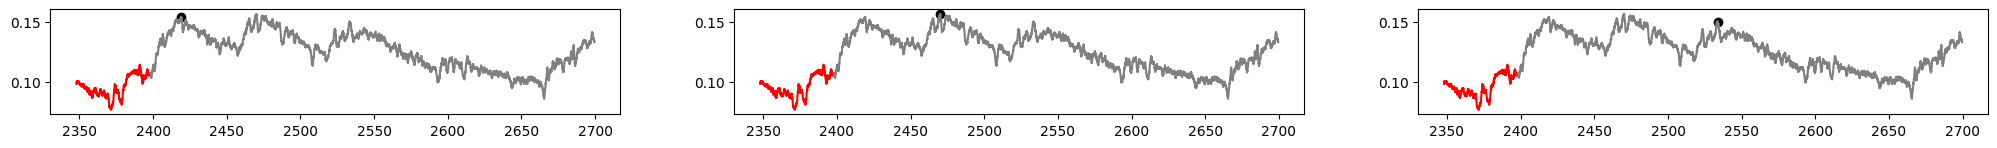

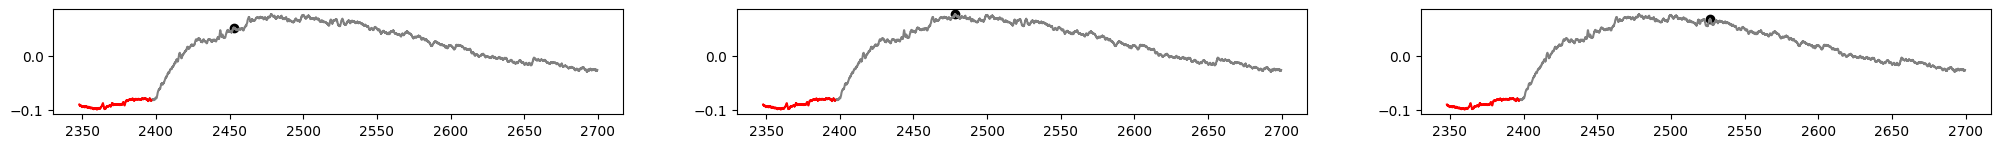

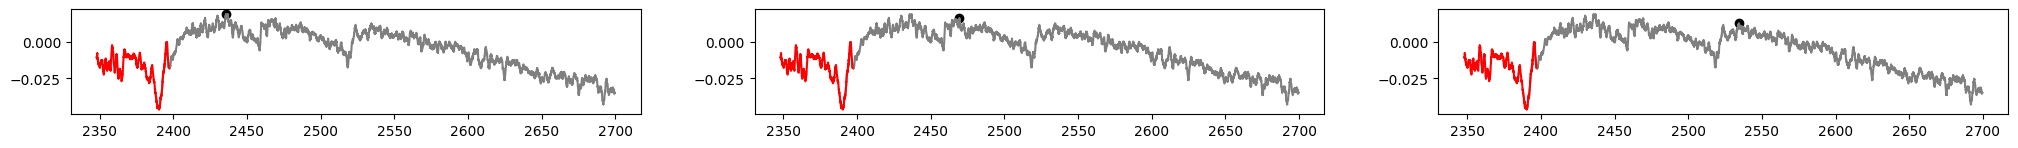

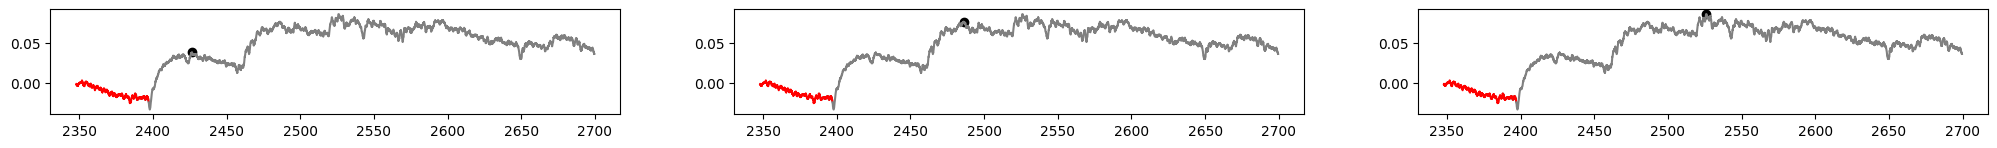

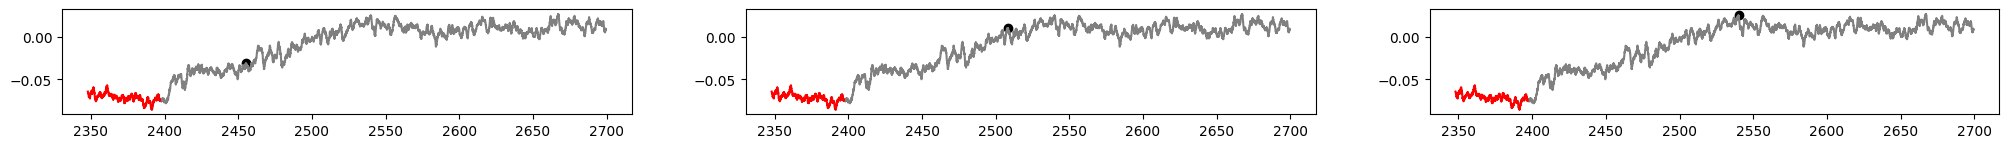

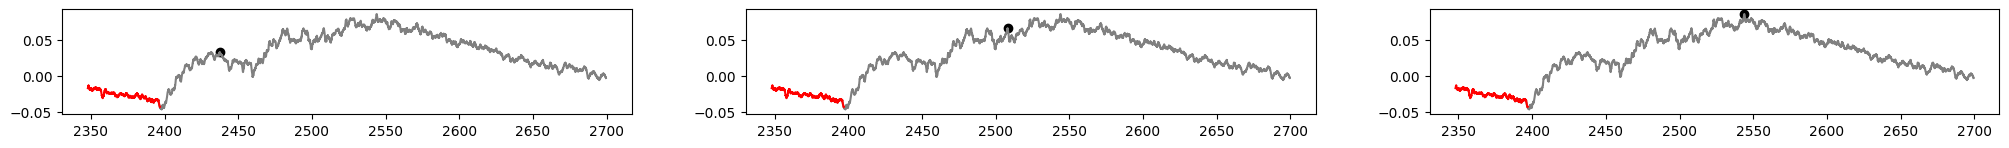

In [ ]:
for i,c in enumerate(Cont_CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(Cont_CNO_puff1_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(Cont_CNO_puff2_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(Cont_CNO_dFF.iloc[puff1_start_post:,i].index, Cont_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(Cont_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], Cont_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(Cont_CNO_puff3_peakInd_pre[i], Cont_CNO_dFF.loc[Cont_CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
def peak_func(dFF_data, peakInd):
    peak_dict = {}

    for i, mouse in enumerate(dFF_data.columns):
        peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]

    return peak_dict

In [ ]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff1_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_CNO': np.float64(0.15421740639825754),
 'Cont2_CNO': np.float64(0.05169169509101612),
 'Cont3_CNO': np.float64(0.01945348024841953),
 'Cont5_CNO': np.float64(0.038229795146462964),
 'Cont6_CNO': np.float64(-0.03131697786685983),
 'Cont7_CNO': np.float64(0.033351864711769874)}

In [ ]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff2_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_CNO': np.float64(0.15655524122338882),
 'Cont2_CNO': np.float64(0.07646117028600097),
 'Cont3_CNO': np.float64(0.01665693364767573),
 'Cont5_CNO': np.float64(0.0770991804815172),
 'Cont6_CNO': np.float64(0.009942261039607603),
 'Cont7_CNO': np.float64(0.06676356692884688)}

In [ ]:
peak_func(Cont_CNO_dFF, Cont_CNO_puff3_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'Cont1_CNO': np.float64(0.15024090782481592),
 'Cont2_CNO': np.float64(0.06802079632448255),
 'Cont3_CNO': np.float64(0.012957559833539523),
 'Cont5_CNO': np.float64(0.08669783436105405),
 'Cont6_CNO': np.float64(0.024861296805681055),
 'Cont7_CNO': np.float64(0.08641182929062019)}

In [ ]:
Cont_CNO_dFF.to_excel('Cont_CNO_dFFF.xlsx')

### hM3Dq 1.0 CNO

In [ ]:
hM3Dq_CNO_puff1_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
hM3Dq_CNO_puff2_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
hM3Dq_CNO_puff3_peakInd_pre = hM3Dq_CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

/tmp/ipython-input-1734161827.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(hM3Dq_CNO_puff1_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff1_peakInd_pre[i],c], color="black")
/tmp/ipython-input-1734161827.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(hM3Dq_CNO_puff2_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff2_peakInd_pre[i],c], color="black")
/tmp/ipython-input-1734161827.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a valu

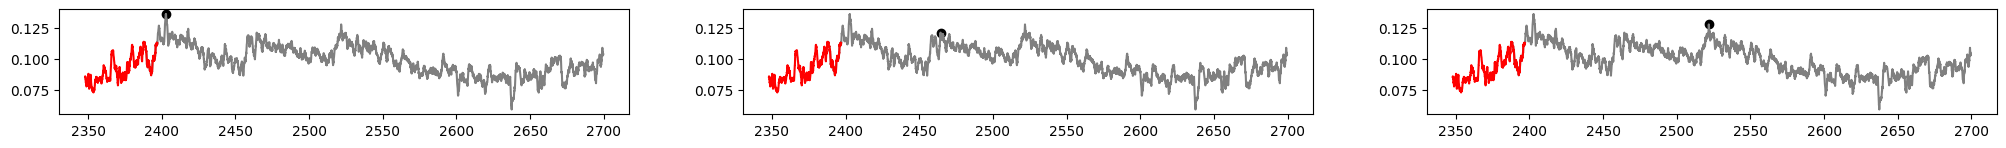

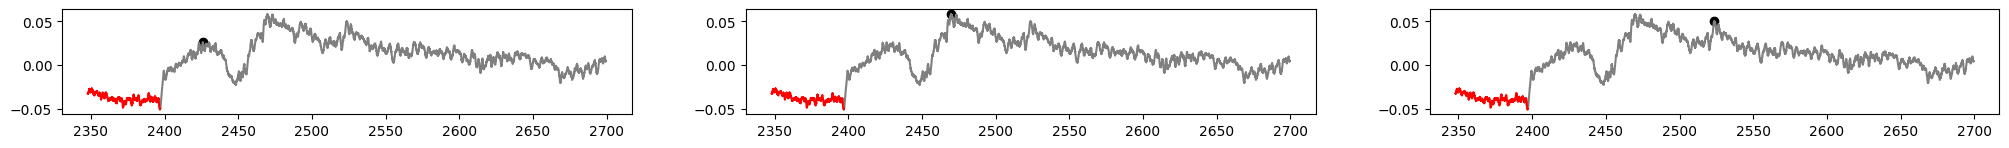

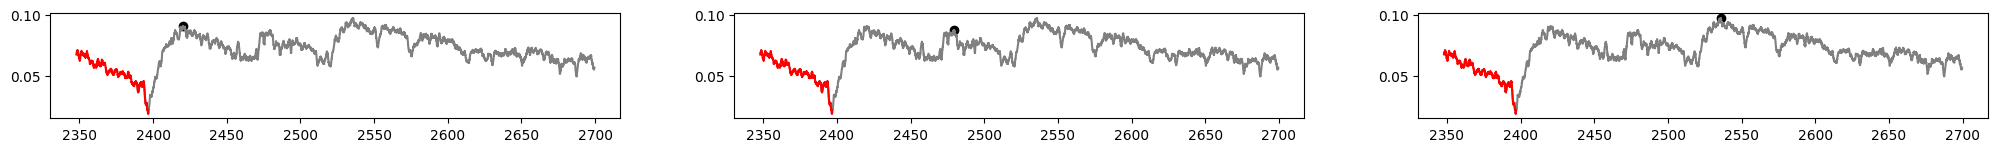

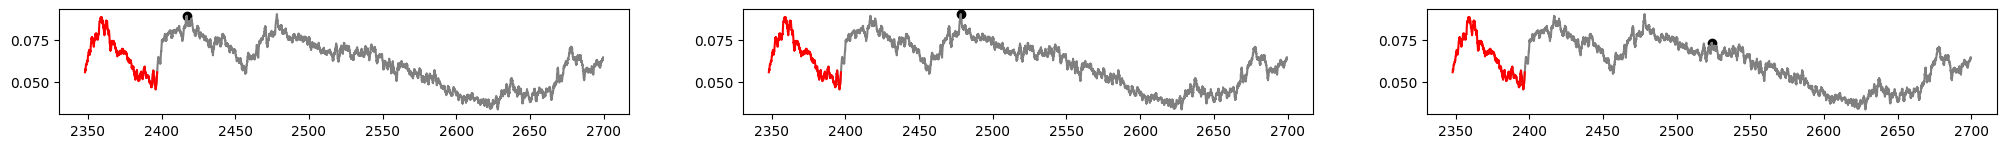

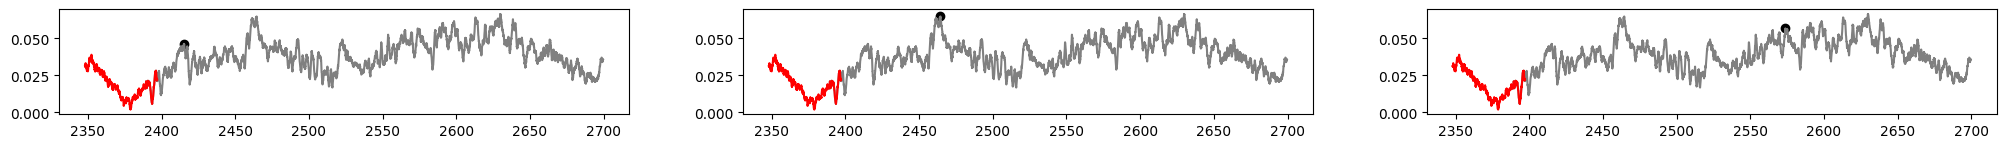

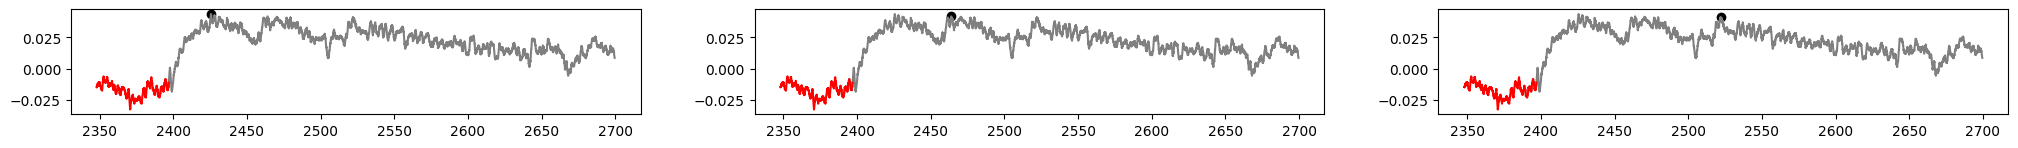

In [ ]:
for i,c in enumerate(hM3Dq_CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(hM3Dq_CNO_puff1_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(hM3Dq_CNO_puff2_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(hM3Dq_CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(hM3Dq_CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(hM3Dq_CNO_puff3_peakInd_pre[i], hM3Dq_CNO_dFF.loc[hM3Dq_CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff1_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_CNO': np.float64(0.1364444200600632),
 'hM3Dq2_CNO': np.float64(0.02616442841020583),
 'hM3Dq3_CNO': np.float64(0.0904914117605774),
 'hM3Dq5_CNO': np.float64(0.08956567265341187),
 'hM3Dq6_CNO': np.float64(0.04629766562993276),
 'hM3Dq7_CNO': np.float64(0.04368507924055143)}

In [ ]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff2_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_CNO': np.float64(0.12133016431290455),
 'hM3Dq2_CNO': np.float64(0.05839239113709094),
 'hM3Dq3_CNO': np.float64(0.08733084616634568),
 'hM3Dq5_CNO': np.float64(0.0906689665187358),
 'hM3Dq6_CNO': np.float64(0.06478313189658991),
 'hM3Dq7_CNO': np.float64(0.04181265724153671)}

In [ ]:
peak_func(hM3Dq_CNO_dFF, hM3Dq_CNO_puff3_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_CNO': np.float64(0.1280026346012273),
 'hM3Dq2_CNO': np.float64(0.050254239852771),
 'hM3Dq3_CNO': np.float64(0.09724053420149714),
 'hM3Dq5_CNO': np.float64(0.07337928818152528),
 'hM3Dq6_CNO': np.float64(0.056714277204039876),
 'hM3Dq7_CNO': np.float64(0.04142656522336918)}

hM3Dq saline

In [ ]:
hM3Dq_saline_puff1_peakInd_pre = hM3Dq_saline_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
hM3Dq_saline_puff2_peakInd_pre = hM3Dq_saline_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
hM3Dq_saline_puff3_peakInd_pre = hM3Dq_saline_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

/tmp/ipython-input-2958654699.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.scatter(hM3Dq_saline_puff1_peakInd_pre[i], hM3Dq_saline_dFF.loc[hM3Dq_saline_puff1_peakInd_pre[i],c], color="black")
/tmp/ipython-input-2958654699.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax2.scatter(hM3Dq_saline_puff2_peakInd_pre[i], hM3Dq_saline_dFF.loc[hM3Dq_saline_puff2_peakInd_pre[i],c], color="black")
/tmp/ipython-input-2958654699.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior)

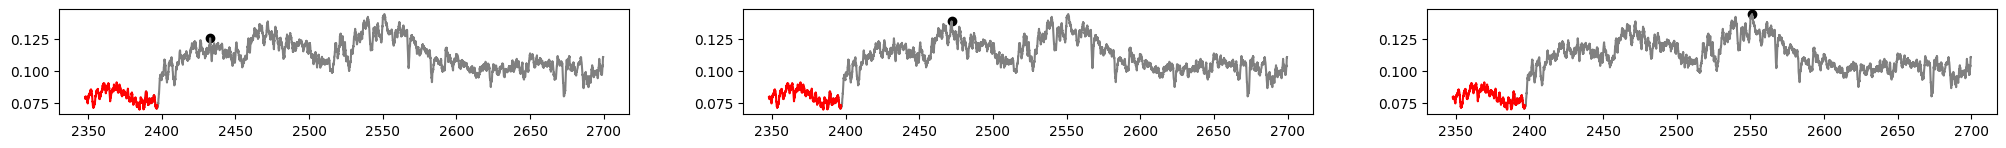

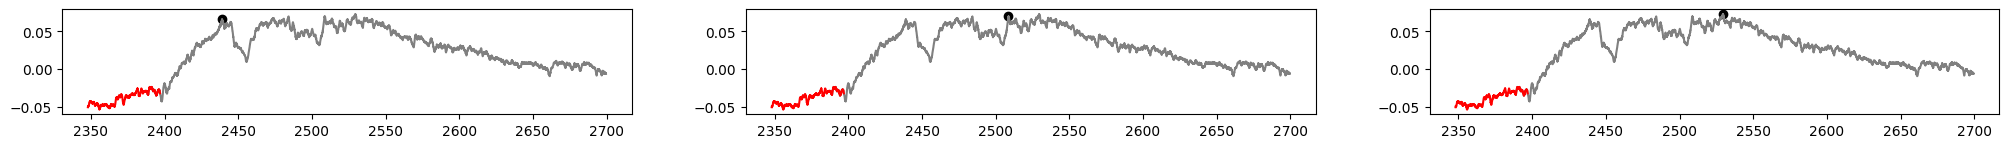

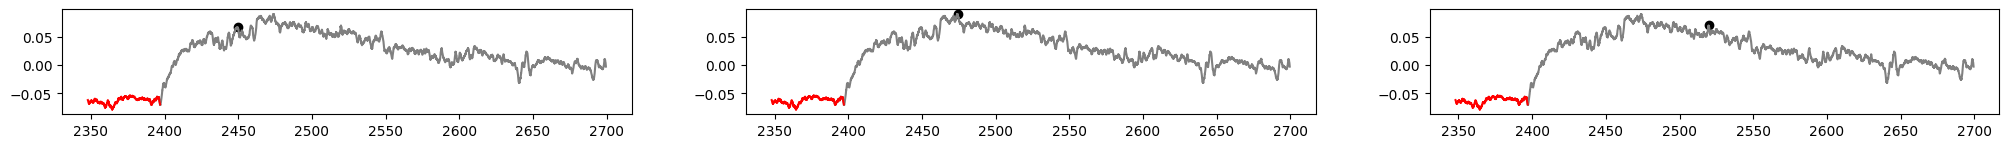

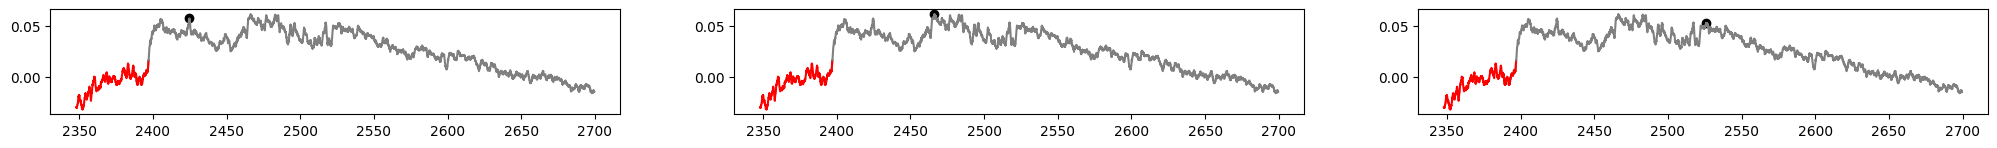

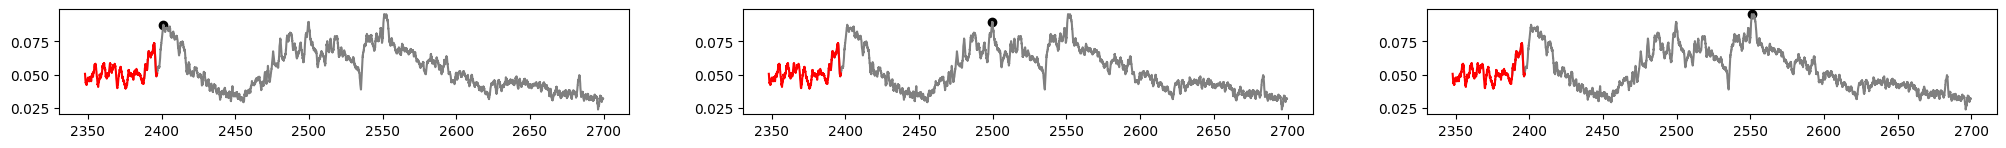

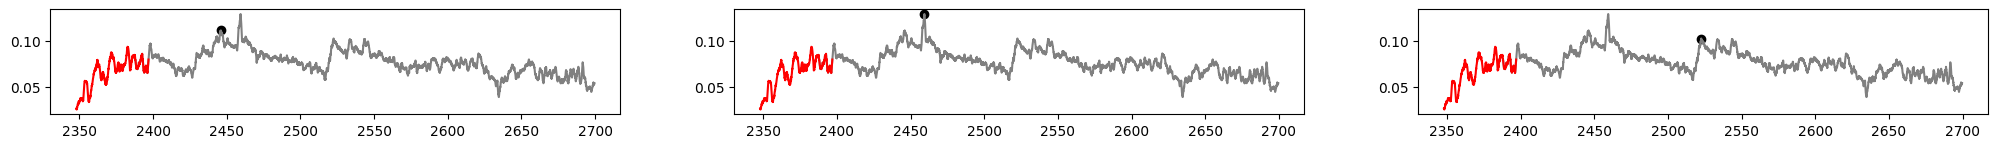

In [ ]:
for i,c in enumerate(hM3Dq_saline_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(hM3Dq_saline_dFF.iloc[puff1_start_post:,i].index, hM3Dq_saline_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(hM3Dq_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(hM3Dq_saline_puff1_peakInd_pre[i], hM3Dq_saline_dFF.loc[hM3Dq_saline_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(hM3Dq_saline_dFF.iloc[puff1_start_post:,i].index, hM3Dq_saline_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(hM3Dq_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(hM3Dq_saline_puff2_peakInd_pre[i], hM3Dq_saline_dFF.loc[hM3Dq_saline_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(hM3Dq_saline_dFF.iloc[puff1_start_post:,i].index, hM3Dq_saline_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(hM3Dq_saline_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_saline_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(hM3Dq_saline_puff3_peakInd_pre[i], hM3Dq_saline_dFF.loc[hM3Dq_saline_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(hM3Dq_saline_dFF, hM3Dq_saline_puff1_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_saline': np.float64(0.12527217045060213),
 'hM3Dq3_saline': np.float64(0.06593783344759885),
 'hM3Dq4_saline': np.float64(0.06670998357233682),
 'hM3Dq5_saline': np.float64(0.05752247972541791),
 'hM3Dq6_saline': np.float64(0.08737151693417322),
 'hM3Dq7_saline': np.float64(0.1117861018883275)}

In [ ]:
peak_func(hM3Dq_saline_dFF, hM3Dq_saline_puff2_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_saline': np.float64(0.138474704348454),
 'hM3Dq3_saline': np.float64(0.0698572625156082),
 'hM3Dq4_saline': np.float64(0.09000389666109943),
 'hM3Dq5_saline': np.float64(0.061844541535828634),
 'hM3Dq6_saline': np.float64(0.08951125852170427),
 'hM3Dq7_saline': np.float64(0.12987196163463777)}

In [ ]:
peak_func(hM3Dq_saline_dFF, hM3Dq_saline_puff3_peakInd_pre)

/tmp/ipython-input-2873964455.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  peak_dict["{}".format(mouse)] = dFF_data.loc[peakInd[i],mouse]


{'hM3Dq1_saline': np.float64(0.14418807427416902),
 'hM3Dq3_saline': np.float64(0.07291263226071054),
 'hM3Dq4_saline': np.float64(0.06987818674324475),
 'hM3Dq5_saline': np.float64(0.05311753484816073),
 'hM3Dq6_saline': np.float64(0.0953734814846755),
 'hM3Dq7_saline': np.float64(0.10294640466761984)}

In [ ]:
hM3Dq_CNO_dFF.to_excel('/content/drive/MyDrive/hM3Dq_CNO_dFF.xlsx')

### hM3Dq 0.1 CNO

In [ ]:
hM3Dq_01CNO_puff1_peakInd_pre = hM3Dq_01CNO_dFF.iloc[puff1_start_post:puff1_end_post,:].idxmax()
hM3Dq_01CNO_puff2_peakInd_pre = hM3Dq_01CNO_dFF.iloc[puff2_start_post:puff2_end_post,:].idxmax()
hM3Dq_01CNO_puff3_peakInd_pre = hM3Dq_01CNO_dFF.iloc[puff3_start_post:puff3_end_post,:].idxmax()

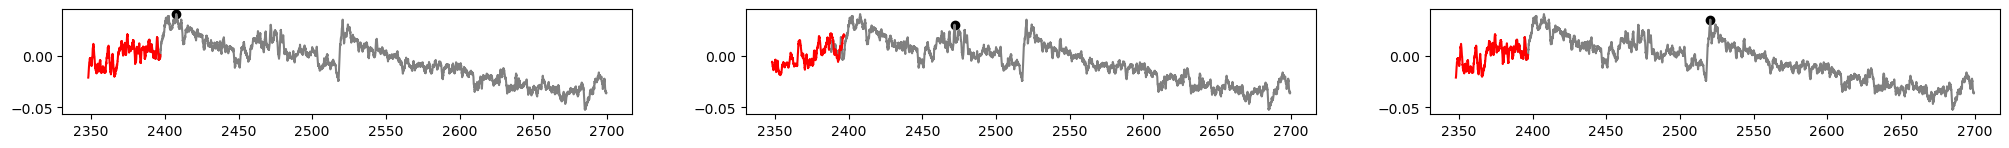

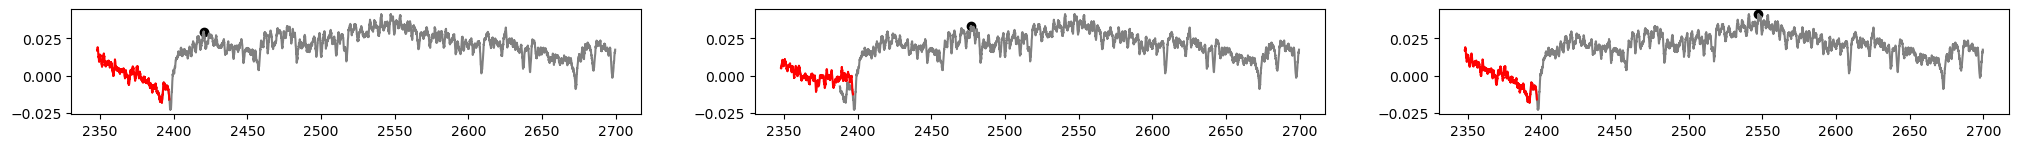

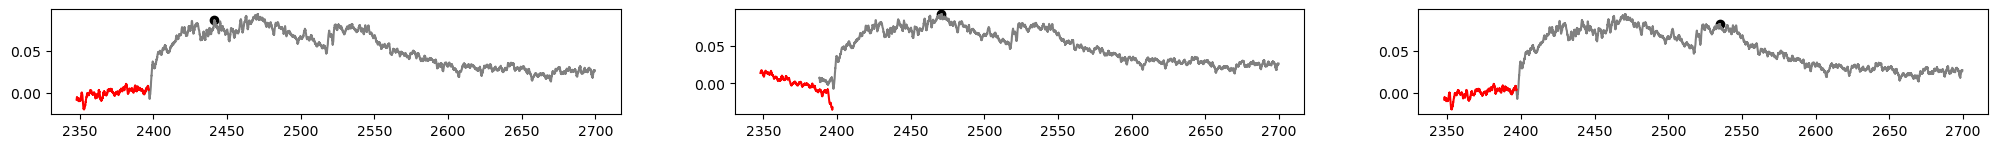

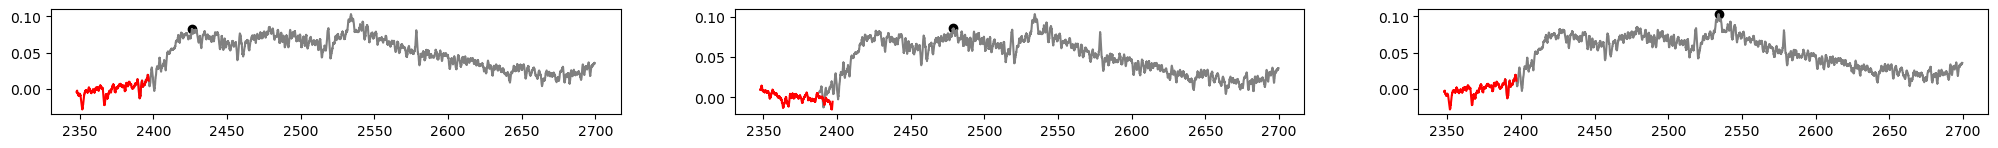

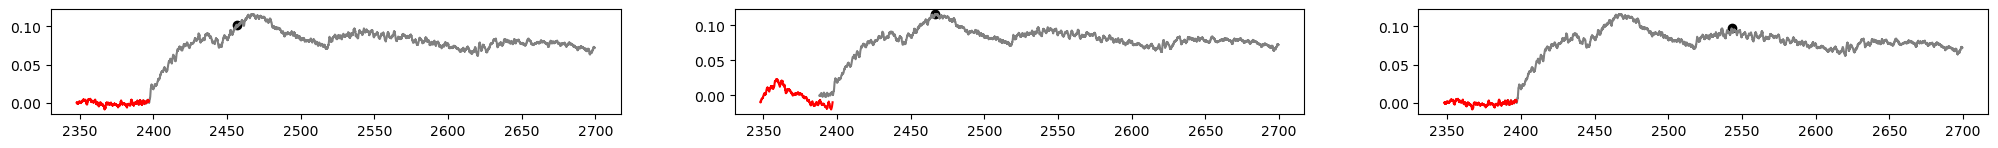

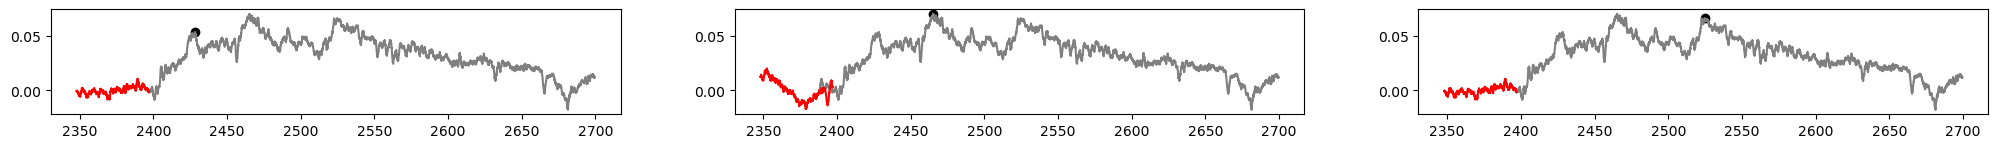

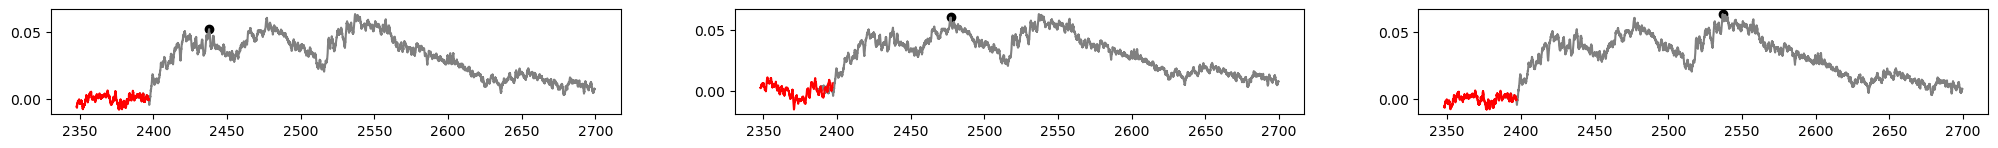

In [ ]:
for i,c in enumerate(hM3Dq_01CNO_dFF.columns):
    fig = plt.figure(figsize=(25, 3))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)


    ax1.plot(hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax1.plot(hM3Dq_01CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_01CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax1.scatter(hM3Dq_01CNO_puff1_peakInd_pre[i], hM3Dq_01CNO_dFF.loc[hM3Dq_01CNO_puff1_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax2.plot(hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax2.plot(hM3Dq_01CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax2.scatter(hM3Dq_01CNO_puff2_peakInd_pre[i], hM3Dq_01CNO_dFF.loc[hM3Dq_01CNO_puff2_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

    ax3.plot(hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i].index, hM3Dq_01CNO_dFF.iloc[puff1_start_post:,i], color="gray")
    ax3.plot(hM3Dq_01CNO_dFF.index[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397)], hM3Dq_01CNO_dFF.iloc[idx_of_the_nearest(time_, 2348):idx_of_the_nearest(time_, 2397), i], color="red")
    ax3.scatter(hM3Dq_01CNO_puff3_peakInd_pre[i], hM3Dq_01CNO_dFF.loc[hM3Dq_01CNO_puff3_peakInd_pre[i],c], color="black")
    #plt.ylim(-0.05, 0.15)

In [ ]:
peak_func(hM3Dq_01CNO_dFF, hM3Dq_01CNO_puff1_peakInd_pre)

{'hM3Dq1_01CNO': 0.04044342902871345,
 'hM3Dq2_01CNO': 0.02963740015007077,
 'hM3Dq3_01CNO': 0.0856594564873715,
 'hM3Dq4_01CNO': 0.08266802050009425,
 'hM3Dq5_01CNO': 0.10229691361948545,
 'hM3Dq6_01CNO': 0.05374320201254312,
 'hM3Dq7_01CNO': 0.051880125567791424}

In [ ]:
peak_func(hM3Dq_01CNO_dFF, hM3Dq_01CNO_puff2_peakInd_pre)

{'hM3Dq1_01CNO': 0.030084441105855175,
 'hM3Dq2_01CNO': 0.03336675411281398,
 'hM3Dq3_01CNO': 0.09302080234017118,
 'hM3Dq4_01CNO': 0.0857513747678258,
 'hM3Dq5_01CNO': 0.11614257540142414,
 'hM3Dq6_01CNO': 0.07010344548921499,
 'hM3Dq7_01CNO': 0.060261291721522836}

In [ ]:
peak_func(hM3Dq_01CNO_dFF, hM3Dq_01CNO_puff3_peakInd_pre)

{'hM3Dq1_01CNO': 0.03502944127007668,
 'hM3Dq2_01CNO': 0.041376740819133895,
 'hM3Dq3_01CNO': 0.08123769295548045,
 'hM3Dq4_01CNO': 0.10334426408779662,
 'hM3Dq5_01CNO': 0.09741457664231323,
 'hM3Dq6_01CNO': 0.06637529233997641,
 'hM3Dq7_01CNO': 0.0630661368836567}

In [ ]:
hM3Dq_01CNO_dFF.to_excel('hM3Dq_01CNO_dFF.xlsx')

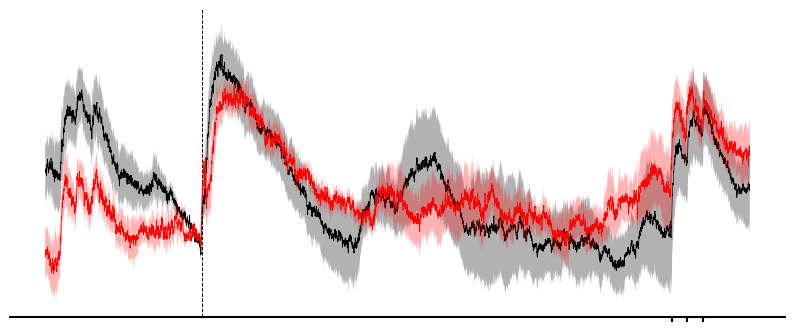

In [ ]:
##figures

Fig_start = idx_of_the_nearest(time_, 0)
Fig_end = idx_of_the_nearest(time_, 2700)

Cont_CNO_mean = Cont_CNO_dFF.mean(axis=1)
hM3Dq_CNO_mean = hM3Dq_CNO_dFF.mean(axis=1)
#Cont_saline_mean = Cont_saline_dFF.mean(axis=1)
#hM3Dq_saline_mean = hM3Dq_saline_dFF.mean(axis=1)

Cont_CNO_SEM = Cont_CNO_dFF.std(axis=1, ddof=1) / np.sqrt(len(Cont_CNO_dFF.columns))
hM3Dq_CNO_SEM = hM3Dq_CNO_dFF.std(axis=1, ddof=1) / np.sqrt(len(hM3Dq_CNO_dFF.columns))
#Cont_saline_SEM = Cont_saline_dFF.std(axis=1, ddof=1) / np.sqrt(len(Cont_saline_dFF.columns))
#hM3Dq_saline_SEM = hM3Dq_saline_dFF.std(axis=1, ddof=1) / np.sqrt(len(hM3Dq_saline_dFF.columns))

plt.figure(figsize=(10,4))
plt.axvline(x=600, color='black', linestyle="--", linewidth=0.7, zorder=1)


plt.fill_between(Cont_CNO_dFF.index[Fig_start:], Cont_CNO_mean.iloc[Fig_start:] - Cont_CNO_SEM.iloc[Fig_start:], \
                Cont_CNO_mean.iloc[Fig_start:] + Cont_CNO_SEM.iloc[Fig_start:], facecolor='black', lw = 0, alpha=0.3, zorder=2)
plt.plot(Cont_CNO_mean.iloc[Fig_start:], lw = 0.5, color="black")

plt.fill_between(hM3Dq_CNO_dFF.index[Fig_start:], hM3Dq_CNO_mean.iloc[Fig_start:] - hM3Dq_CNO_SEM.iloc[Fig_start:], \
                 hM3Dq_CNO_mean.iloc[Fig_start:] + hM3Dq_CNO_SEM.iloc[Fig_start:], facecolor='red', lw = 0, alpha=0.3, zorder=2)
plt.plot(hM3Dq_CNO_mean.iloc[Fig_start:], lw = 0.5, color="red")

#plt.fill_between(Cont_saline_dFF.index[Fig_start:], Cont_saline_mean.iloc[Fig_start:] - Cont_saline_SEM.iloc[Fig_start:], \
#                Cont_saline_mean.iloc[Fig_start:] + Cont_saline_SEM.iloc[Fig_start:], facecolor='gray', lw = 0, alpha=0.3, zorder=2)
#plt.plot(Cont_saline_mean.iloc[Fig_start:], lw = 0.5, color="gray")

#plt.fill_between(hM3Dq_saline_dFF.index[Fig_start:], hM3Dq_saline_mean.iloc[Fig_start:] - hM3Dq_saline_SEM.iloc[Fig_start:], \
#                 hM3Dq_saline_mean.iloc[Fig_start:] + hM3Dq_saline_SEM.iloc[Fig_start:], facecolor='magenta', lw = 0, alpha=0.3, zorder=2)
#plt.plot(hM3Dq_saline_mean.iloc[Fig_start:], lw = 0.5, color="magenta")


#plt.ylim(-0.025, 0.12)
plt.xticks([2400, 2460, 2520])


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines["bottom"].set_linewidth(1.5)
plt.tick_params(length=3.5, width=1.5)
plt.tick_params(labelbottom=False, labelleft=False)
plt.tick_params(left=False, right=False, top=False)

#plt.savefig("cAMP_hab.png", format="png", dpi=300, transparent=True)

plt.show()